# Week19 - Categorical EDA

## Goal
Analyze categorical variables and compare default rates across different borrower groups.

In [25]:
import pandas as pd

In [26]:
import numpy as np

In [27]:
import matplotlib.pyplot as plt

In [28]:
import seaborn as sns

In [29]:
clean_df=pd.read_csv('credit_risk_cleaned.csv')

In [30]:
clean_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [31]:
loan_grade_summary = clean_df.groupby('loan_grade')['loan_status'].agg(['count','mean']).reset_index()
loan_grade_summary 

,loan_grade,count,mean
0,A,10776,0.099573
1,B,10448,0.162806
2,C,6456,0.207404
3,D,3625,0.590345
4,E,964,0.644191
5,F,241,0.705394
6,G,64,0.984375


In [32]:
loan_grade_summary = loan_grade_summary.sort_values('loan_grade')
loan_grade_summary

,loan_grade,count,mean
0,A,10776,0.099573
1,B,10448,0.162806
2,C,6456,0.207404
3,D,3625,0.590345
4,E,964,0.644191
5,F,241,0.705394
6,G,64,0.984375


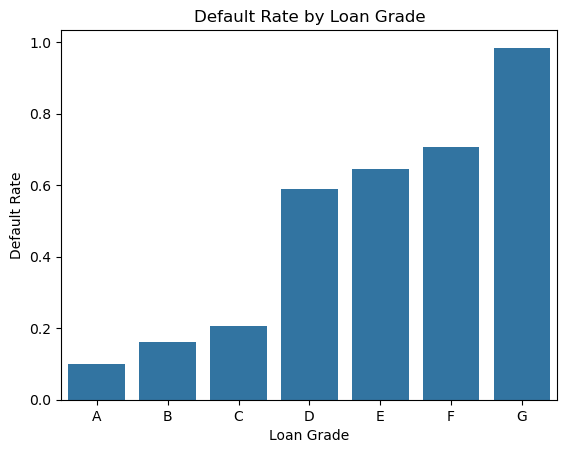

In [33]:
sns.barplot(x='loan_grade', y='mean', data=loan_grade_summary)
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.show()

## Loan Grade Insight

- Default rate changes across loan grades.
- Lower loan grades tend to show higher default risk.
- Loan grade appears to be an important categorical risk indicator.

In [34]:
default_history_summary = clean_df.groupby('cb_person_default_on_file')['loan_status'].agg(['count','mean']).reset_index()
default_history_summary

,cb_person_default_on_file,count,mean
0,N,26830,0.183973
1,Y,5744,0.377960


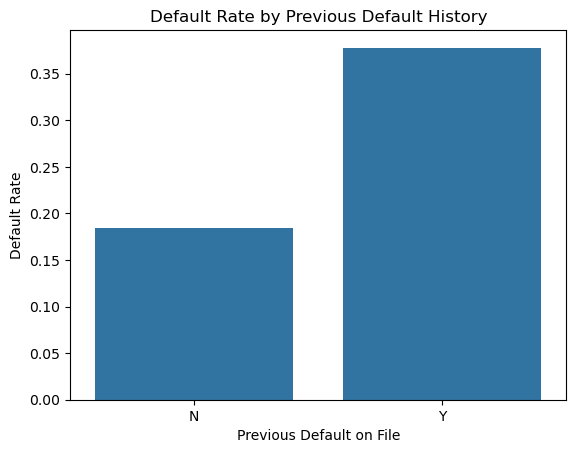

In [35]:
sns.barplot(x='cb_person_default_on_file', y='mean', data=default_history_summary)
plt.title('Default Rate by Previous Default History')
plt.xlabel('Previous Default on File')
plt.ylabel('Default Rate')
plt.show()

## Previous Default History Insight

- Borrowers with previous default history ('Y') have a significantly higher current default rate than borrowers with no previous default history ('N').
- The default rate for borrowers with previous defaults is approximately twice as high, suggesting that past default behavior is a strong indicator of future credit risk.

In [36]:
home_summary = clean_df.groupby('person_home_ownership')['loan_status'].agg(['count','mean']).reset_index()
home_summary

,person_home_ownership,count,mean
0,MORTGAGE,13441,0.125735
1,OTHER,107,0.308411
2,OWN,2584,0.074690
3,RENT,16442,0.315716


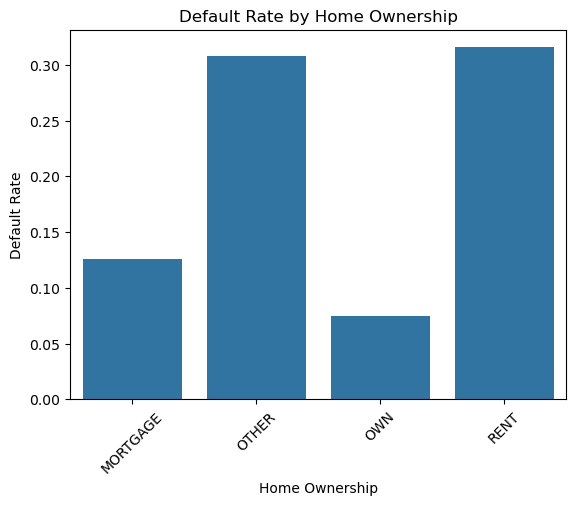

In [37]:
sns.barplot(x='person_home_ownership', y='mean', data=home_summary)
plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

## Home Ownership Insight

- Borrowers who rent their homes show a higher default rate than borrowers who own homes.
- Borrowers who fully own their homes have the lowest default rate.
- This suggests that home ownership status may be related to financial stability and credit risk.

In [38]:
loan_intent_summary = clean_df.groupby('loan_intent')['loan_status'].agg(['count', 'mean']).reset_index()
loan_intent_summary

,loan_intent,count,mean
0,DEBTCONSOLIDATION,5212,0.285879
1,EDUCATION,6451,0.172221
2,HOMEIMPROVEMENT,3605,0.261026
3,MEDICAL,6071,0.267007
4,PERSONAL,5519,0.198768
5,VENTURE,5716,0.148181


In [39]:
loan_intent_summary = loan_intent_summary.sort_values('mean', ascending=False)
loan_intent_summary

,loan_intent,count,mean
0,DEBTCONSOLIDATION,5212,0.285879
3,MEDICAL,6071,0.267007
2,HOMEIMPROVEMENT,3605,0.261026
4,PERSONAL,5519,0.198768
1,EDUCATION,6451,0.172221
5,VENTURE,5716,0.148181


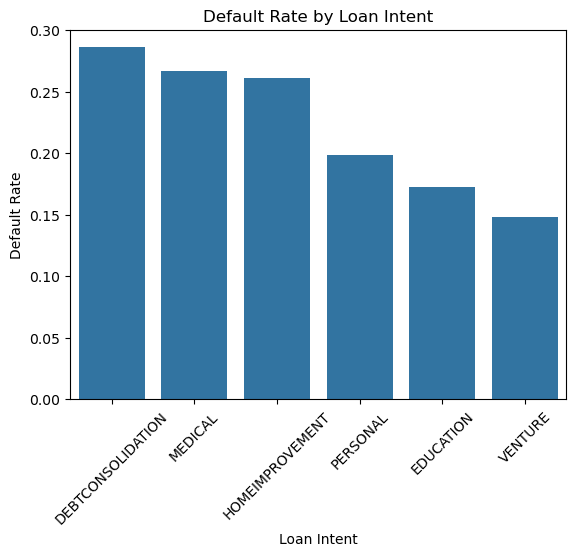

In [40]:
sns.barplot(x='loan_intent', y='mean', data=loan_intent_summary)
plt.title('Default Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

## Loan Intent Insight

- Default rates are different across loan purposes.
- Debt consolidation, medical, and home improvement loans have the highest default rates, but the gap among them is small.
- Education and venture loans have clearly lower default rates.
- Loan intent may help identify lower-risk and higher-risk borrower groups.

In [41]:
clean_df['burden_group'] = pd.qcut(
    clean_df['loan_percent_income'],
    q=3,
    labels=['low_burden', 'medium_burden', 'high_burden']
)

In [44]:
clean_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,burden_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,low_burden
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,high_burden
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,high_burden
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,high_burden
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,high_burden


In [45]:
burden_summary = clean_df.groupby('burden_group')['loan_status'].agg(['mean', 'count']).reset_index()
burden_summary

,burden_group,mean,count
0,low_burden,0.118540,11861
1,medium_burden,0.154048,10685
2,high_burden,0.404368,10028


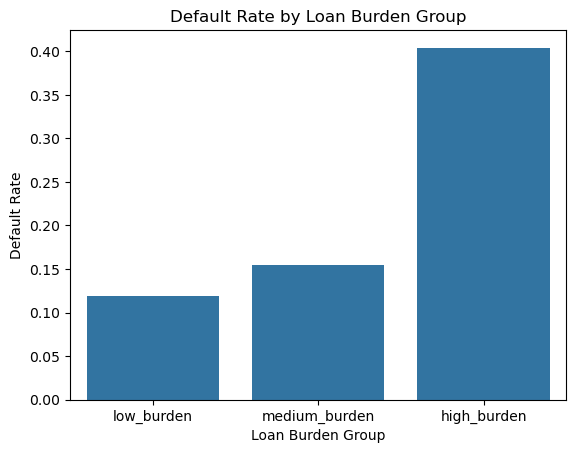

In [46]:
sns.barplot(x='burden_group', y='mean', data=burden_summary)
plt.title('Default Rate by Loan Burden Group')
plt.xlabel('Loan Burden Group')
plt.ylabel('Default Rate')
plt.show()

In [48]:
grade_burden_summary = clean_df.groupby(['loan_grade', 'burden_group'])['loan_status'].mean().reset_index()
grade_burden_summary

,loan_grade,burden_group,loan_status
0,A,low_burden,0.037678
1,A,medium_burden,0.050782
2,A,high_burden,0.278816
3,B,low_burden,0.074891
4,B,medium_burden,0.081517
5,B,high_burden,0.336446
6,C,low_burden,0.112113
7,C,medium_burden,0.136560
8,C,high_burden,0.388535
9,D,low_burden,0.516129


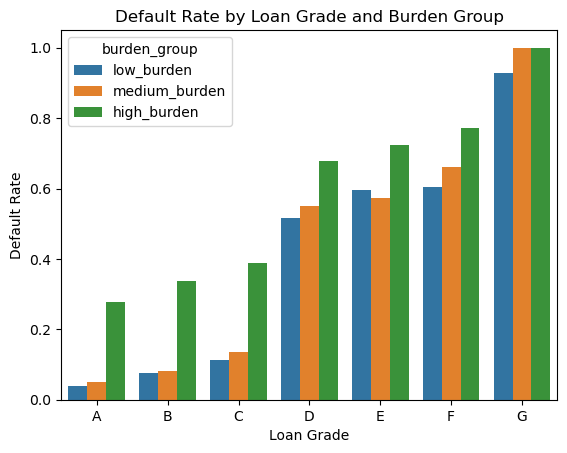

In [51]:
sns.barplot(x='loan_grade', y='loan_status', hue='burden_group', data=grade_burden_summary)
plt.title('Default Rate by Loan Grade and Burden Group')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.show()

## Risk Segmentation Insight

- Loan grade appears to be the main factor related to default risk. Default rate generally increases from grade A to grade G.
- Loan burden provides an additional layer of risk separation within each grade.
- This pattern is especially clear in grades A, B, and C, where high-burden borrowers have much higher default rates than low- and medium-burden borrowers.
- This suggests that combining loan grade with loan burden can help identify hidden risk among borrowers who otherwise appear to have stronger credit profiles.

In [52]:
loan_grade_summary.to_csv('loan_grade_summary.csv', index=False)
default_history_summary.to_csv('default_history_summary.csv', index=False)
home_summary.to_csv('home_ownership_summary.csv', index=False)
loan_intent_summary.to_csv('loan_intent_summary.csv', index=False)
burden_summary.to_csv('burden_group_summary.csv', index=False)
grade_burden_summary.to_csv('grade_burden_summary.csv', index=False)